In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv('Parking Dataset.csv')
df

,SystemCodeNumber,Capacity,Occupancy,LastUpdated
0,BHMBCCMKT01,577,61,2016-10-04 07:59:42
1,BHMBCCMKT01,577,64,2016-10-04 08:25:42
2,BHMBCCMKT01,577,80,2016-10-04 08:59:42
3,BHMBCCMKT01,577,107,2016-10-04 09:32:46
4,BHMBCCMKT01,577,150,2016-10-04 09:59:48
...,...,...,...,...
35712,Shopping,1920,1517,2016-12-19 14:30:33
35713,Shopping,1920,1487,2016-12-19 15:03:34
35714,Shopping,1920,1432,2016-12-19 15:29:33
35715,Shopping,1920,1321,2016-12-19 16:03:35


In [3]:
df['LastUpdated'] = pd.to_datetime(df['LastUpdated'])
df = df.sort_values(['SystemCodeNumber','LastUpdated']).reset_index(drop=True)
df = df.drop_duplicates(subset=['SystemCodeNumber','LastUpdated'])
df = df[(df['Occupancy'] >= 0) & (df['Occupancy'] <= df['Capacity'])]

In [4]:
df['hour'] = df['LastUpdated'].dt.hour
df['day_of_week'] = df['LastUpdated'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)
df['occupancy_rate'] = df['Occupancy'] / df['Capacity']

group = df.groupby('SystemCodeNumber')['Occupancy']
df['occ_lag_1'] = group.shift(1)
df['occ_lag_2'] = group.shift(2)
df = df.dropna().reset_index(drop=True)

In [5]:
def categorize(r):
    if r < 0.5: return 0      # Low
    elif r < 0.8: return 1    # Medium
    else: return 2            # High

df['status'] = df['occupancy_rate'].apply(categorize)
class_names = ['Low', 'Medium', 'High']

In [6]:
features = ['Capacity','hour','day_of_week','is_weekend',
            'occupancy_rate','occ_lag_1','occ_lag_2']

X = df[features].values
y = df['status'].values

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [9]:
rf = RandomForestClassifier(n_estimators=150, random_state=42)
rf.fit(X_train_scaled, y_train)
rf_pred = rf.predict(X_test_scaled)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred, target_names=class_names))

Random Forest Accuracy: 1.0
              precision    recall  f1-score   support

         Low       1.00      1.00      1.00      3715
      Medium       1.00      1.00      1.00      2157
        High       1.00      1.00      1.00      1140

    accuracy                           1.00      7012
   macro avg       1.00      1.00      1.00      7012
weighted avg       1.00      1.00      1.00      7012



In [10]:
dt = DecisionTreeClassifier(max_depth=10, random_state=42)
dt.fit(X_train_scaled, y_train)
dt_pred = dt.predict(X_test_scaled)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print(classification_report(y_test, dt_pred, target_names=class_names))

Decision Tree Accuracy: 1.0
              precision    recall  f1-score   support

         Low       1.00      1.00      1.00      3715
      Medium       1.00      1.00      1.00      2157
        High       1.00      1.00      1.00      1140

    accuracy                           1.00      7012
   macro avg       1.00      1.00      1.00      7012
weighted avg       1.00      1.00      1.00      7012



In [11]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred, target_names=class_names))

Logistic Regression Accuracy: 0.9971477467199087
              precision    recall  f1-score   support

         Low       1.00      1.00      1.00      3715
      Medium       1.00      1.00      1.00      2157
        High       1.00      0.99      1.00      1140

    accuracy                           1.00      7012
   macro avg       1.00      1.00      1.00      7012
weighted avg       1.00      1.00      1.00      7012



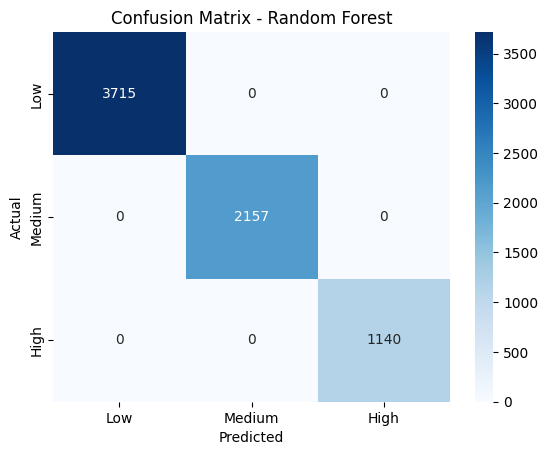

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.show()